# FloodSense — Notebook 1: Exploratory Data Analysis

**Goal:** Thoroughly understand the data before any modelling.

Sections:

1. Load Libraries
2. Load Datasets
3. Basic Shape & Types
4. Missing Values
5. Duplicate Rows
6. Class Balance (flood vs non-flood)
7. Phantom / Impossible Values
8. Distribution of Each Feature (Normality Check)
9. Box Plots — Outlier Inspection per Class
10. IQR Outlier Count per Feature (Non-Flood Class)
11. Correlation Analysis
12. Feature vs Target (Flood vs No-Flood means)
13. Time Series Patterns
14. Seasonal / Monthly Patterns
15. Summary & Notes for Modelling


## 1. Load Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="muted")
print("Libraries loaded.")

Libraries loaded.


## 2. Load Datasets


In [2]:
raw = pd.read_csv("floodsense_training_data.csv", parse_dates=["date"])
elev = pd.read_csv("district_elevation_reference.csv")
ndma = pd.read_csv("ndma_flood_impact_2022.csv")

print("Training data :", raw.shape)
print("Elevation ref :", elev.shape)
print("NDMA impact   :", ndma.shape)

Training data : (1434, 25)
Elevation ref : (5, 3)
NDMA impact   : (7, 14)


In [3]:
# Merge elevation on district
df = raw.merge(elev[["district", "avg_elevation_m"]], on="district", how="left")
print("After merge:", df.shape)
df.head(3)

After merge: (1434, 26)


,date,elevation,evaporation,latitude,longitude,precipitation,pressure,soil_moisture,temperature,water_area_km2,wind_speed,humidity,precip_3day_avg,precip_7day_avg,temp_3day_avg,soil_3day_avg,day_of_year,month,year,is_monsoon,water_area_change,water_area_pct_change,ds_idx,flood_event,district,avg_elevation_m
0,2024-08-21,275.0,-0.002420,34.02,71.98,NaN,99056.47984,0.278052,30.120004,651.439640,2.287565,75.386454,0.015525,0.269450,29.455034,0.305728,234.0,8,2024,1,-139.274059,-0.176137,1.0,0,KP_District,285
1,2022-09-17,109.0,-0.002011,26.25,68.00,0.001034,98899.29858,0.127672,28.925564,316.305625,3.693490,66.599650,0.003241,0.052370,29.614355,0.135051,260.0,9,2022,1,-306.647003,-0.492248,2.0,0,Sindh_District,109
2,2024-04-17,275.0,-0.000326,34.02,71.98,0.064778,99683.73637,0.094294,28.598953,334.627838,0.173182,44.505399,0.033527,0.087449,28.481257,0.098971,108.0,4,2024,0,334.243792,870.321111,9.0,0,KP_District,285


## 3. Basic Shape & Data Types


In [4]:
print(f"Rows : {df.shape[0]}")
print(f"Cols : {df.shape[1]}")
print()
print(df.dtypes)

Rows : 1434
Cols : 26

date                     datetime64[us]
elevation                       float64
evaporation                     float64
latitude                        float64
longitude                       float64
precipitation                   float64
pressure                        float64
soil_moisture                   float64
temperature                     float64
water_area_km2                  float64
wind_speed                      float64
humidity                        float64
precip_3day_avg                 float64
precip_7day_avg                 float64
temp_3day_avg                   float64
soil_3day_avg                   float64
day_of_year                     float64
month                             int64
year                              int64
is_monsoon                        int64
water_area_change               float64
water_area_pct_change           float64
ds_idx                          float64
flood_event                       int64
district         

In [5]:
# Quick statistical summary
df.describe().T

c:\Users\drstr\Downloads\BNU_Fest\.venv\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,min,25%,50%,75%,max,std
date,1434,2023-06-28 15:45:56.485355,2022-01-01 00:00:00,2022-09-30 06:00:00,2023-06-26 12:00:00,2024-03-26 18:00:00,2024-12-30 00:00:00,NaN
elevation,1433.0,216.443126,58.0,58.0,109.0,275.0,99999.0,2639.371277
evaporation,1432.0,-0.000561,-0.00328,-0.000587,-0.000258,-0.000153,-0.000068,0.000695
latitude,1432.0,29.891369,26.25,26.25,29.5,34.02,34.02,3.187158
longitude,1432.0,69.311844,68.0,68.0,68.0,71.98,71.98,1.871537
precipitation,1214.0,-0.441485,-999.0,0.0,0.000411,0.005965,387.4,30.763356
pressure,1432.0,99544.431803,84200.0,98881.455965,99542.90733,100222.13015,101050.6959,848.240112
soil_moisture,1433.0,0.119722,0.079309,0.085429,0.087128,0.095062,5.0,0.149363
temperature,1433.0,26.364512,-999.0,21.52155,28.895636,32.019267,58.3,27.883724
water_area_km2,1432.0,585.362749,0.0,248.777487,511.365663,870.881495,2944.531603,441.577648


## 4. Missing Values


In [6]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({"null_count": null_counts, "null_%": null_pct})
null_df = null_df[null_df["null_count"] > 0].sort_values("null_count", ascending=False)

if null_df.empty:
    print("No missing values found.")
else:
    print(null_df)

                       null_count  null_%
precipitation                 220   15.34
latitude                        2    0.14
evaporation                     2    0.14
day_of_year                     2    0.14
longitude                       2    0.14
pressure                        2    0.14
water_area_km2                  2    0.14
wind_speed                      2    0.14
temp_3day_avg                   2    0.14
precip_7day_avg                 2    0.14
precip_3day_avg                 2    0.14
ds_idx                          2    0.14
water_area_change               2    0.14
water_area_pct_change           2    0.14
soil_3day_avg                   2    0.14
elevation                       1    0.07
humidity                        1    0.07
soil_moisture                   1    0.07
temperature                     1    0.07


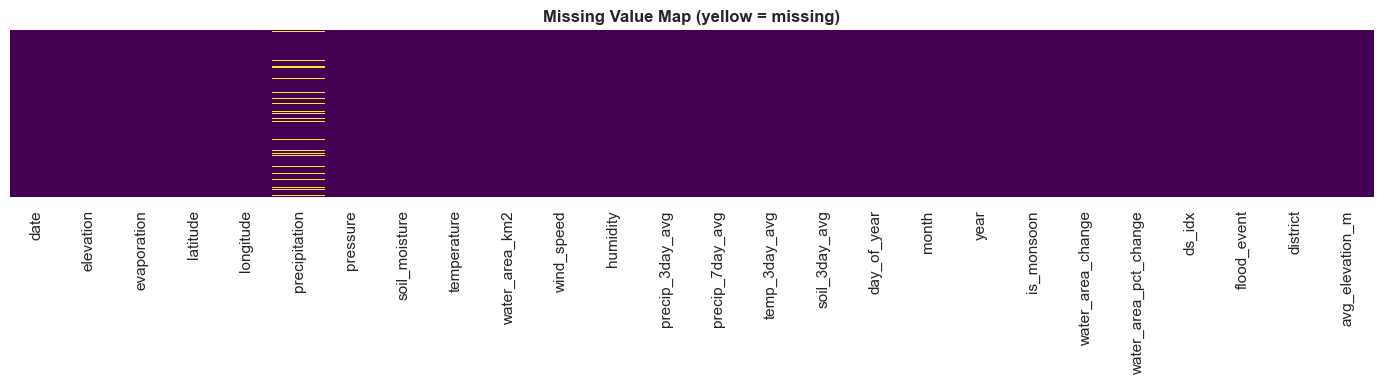

In [7]:
# Visualise missing values as a heatmap
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Value Map (yellow = missing)", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Duplicate Rows


In [8]:
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup} ({n_dup/len(df)*100:.2f}%)")

if n_dup > 0:
    print("\nSample duplicates:")
    display(df[df.duplicated(keep=False)].head(6))

Duplicate rows: 67 (4.67%)

Sample duplicates:


,date,elevation,evaporation,latitude,longitude,precipitation,pressure,soil_moisture,temperature,water_area_km2,wind_speed,humidity,precip_3day_avg,precip_7day_avg,temp_3day_avg,soil_3day_avg,day_of_year,month,year,is_monsoon,water_area_change,water_area_pct_change,ds_idx,flood_event,district,avg_elevation_m
8,2023-12-26,58.0,-0.000078,29.50,68.00,0.000362,100552.82740,0.085388,18.782902,236.056887,0.634622,51.115953,0.000121,0.000573,18.325145,0.085424,360.0,12,2023,0,-166.857930,-0.414127,6.0,0,Balochistan_District,610
15,2024-03-28,275.0,-0.000127,34.02,71.98,NaN,99898.01449,0.084453,27.691314,707.178622,3.038088,48.773538,0.001249,0.003571,30.030872,0.084435,88.0,3,2024,0,-152.684686,-0.177569,1.0,0,KP_District,285
35,2022-09-05,109.0,-0.002607,26.25,68.00,0.017655,99064.31805,0.232914,28.438179,379.139598,2.503228,75.006716,0.012584,0.093623,28.238041,0.246685,248.0,9,2022,1,-366.549807,-0.491558,2.0,0,Sindh_District,109
46,2024-11-29,275.0,-0.000196,34.02,71.98,0.000430,100262.96740,0.085901,24.213522,64.340110,1.537468,58.033924,0.000644,0.000831,24.141283,0.085893,334.0,11,2024,0,-63.227254,-0.495638,11.0,0,KP_District,285
51,2022-03-03,109.0,-0.000254,26.25,68.00,NaN,100460.86740,0.096560,21.343686,633.712646,0.849526,56.820600,0.040365,0.017407,21.597384,0.093416,62.0,3,2022,0,-246.647701,-0.280167,1.0,0,Sindh_District,109
52,2023-10-09,58.0,-0.000224,29.50,68.00,0.000000,99591.82798,0.084912,31.178546,1212.168410,2.878216,46.575252,0.000037,0.000180,31.245126,0.084926,282.0,10,2023,0,592.510993,0.956191,0.0,1,Balochistan_District,610


## 6. Class Balance - Flood vs Non-Flood


In [9]:
counts = df["flood_event"].value_counts()
pcts = df["flood_event"].value_counts(normalize=True) * 100

balance = pd.DataFrame({"count": counts, "percent_%": pcts.round(2)})
balance.index = ["No Flood (0)", "Flood (1)"]
print(balance)
print(f"\nImbalance ratio (non-flood : flood) = {counts[0]/counts[1]:.2f} : 1")

              count  percent_%
No Flood (0)    970      67.64
Flood (1)       464      32.36

Imbalance ratio (non-flood : flood) = 2.09 : 1


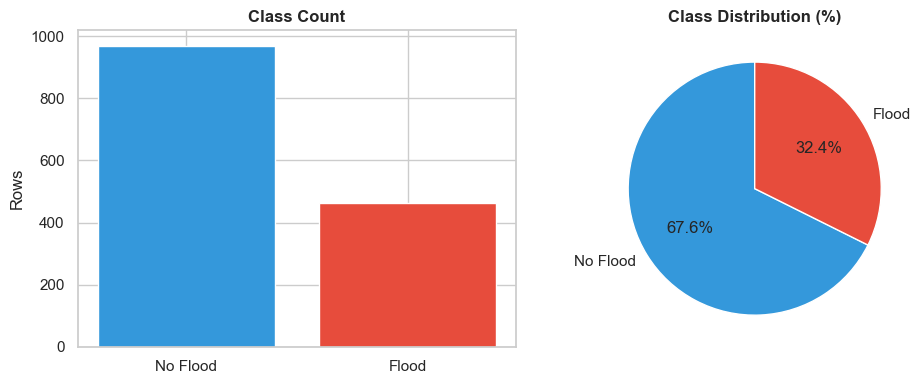

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["No Flood", "Flood"], counts.values, color=["#3498DB", "#E74C3C"])
axes[0].set_title("Class Count", fontweight="bold")
axes[0].set_ylabel("Rows")

axes[1].pie(
    pcts.values,
    labels=["No Flood", "Flood"],
    colors=["#3498DB", "#E74C3C"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Class Distribution (%)", fontweight="bold")

plt.tight_layout()
plt.show()

## 7. Phantom / Impossible Values


In [11]:
# Check for infinite values
num_df = df.select_dtypes(include=[np.number])
inf_counts = np.isinf(num_df).sum()
inf_counts = inf_counts[inf_counts > 0]

if inf_counts.empty:
    print("No infinite values found.")
else:
    print("Columns with inf values:")
    print(inf_counts)

Columns with inf values:
water_area_pct_change    1
dtype: int64


In [ ]:
# Physical range checks - domain knowledge thresholds
checks = {
    "precipitation": (0, 1500),
    "temperature": (-10, 55),
    "humidity": (0, 100),
    "pressure": (870, 1085),
    "soil_moisture": (0, 100),
    "wind_speed": (0, 200),
}

print("Phantom value counts (outside physical range):")
for col, (lo, hi) in checks.items():
    if col in df.columns:
        bad = ((df[col] < lo) | (df[col] > hi)).sum()
        print(f"  {col:25s}  [{lo}, {hi}]  →  {bad} violations")

Phantom value counts (outside physical range):
  precipitation              [0, 1500]  →  1 violations
  temperature                [-10, 55]  →  2 violations
  humidity                   [0, 100]  →  1 violations
  pressure                   [870, 1085]  →  1432 violations
  soil_moisture              [0, 100]  →  0 violations
  wind_speed                 [0, 200]  →  0 violations


## 8. Distribution of Each Feature (Normality Check)


In [13]:
# Skewness of all numeric columns
skip = {"flood_event", "month", "year", "day_of_year", "is_monsoon"}
num_features = [
    c for c in df.select_dtypes(include=[np.number]).columns if c not in skip
]

skew_df = pd.DataFrame(
    {
        "skewness": df[num_features].skew().round(3),
        "kurtosis": df[num_features].kurtosis().round(3),
    }
).sort_values("skewness", key=abs, ascending=False)

print("Feature skewness (|skew| > 1 → likely non-normal, needs transformation):")
print(skew_df)

Feature skewness (|skew| > 1 → likely non-normal, needs transformation):
                       skewness  kurtosis
elevation                37.785  1429.489
temperature             -34.775  1279.292
precipitation           -26.586   937.623
soil_moisture            24.725   796.827
wind_speed                9.802   224.837
precip_3day_avg           8.576    98.094
precip_7day_avg           6.579    53.438
pressure                 -4.153    73.231
soil_3day_avg             2.701     6.256
evaporation              -2.001     3.050
water_area_change         1.503     2.739
water_area_km2            0.915     1.150
longitude                 0.726    -1.475
ds_idx                    0.642    -0.736
humidity                  0.576     4.555
temp_3day_avg            -0.521    -0.856
avg_elevation_m           0.353    -1.499
latitude                  0.212    -1.495
water_area_pct_change       NaN       NaN


c:\Users\drstr\Downloads\BNU_Fest\.venv\Lib\site-packages\pandas\core\nanops.py:1274: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
c:\Users\drstr\Downloads\BNU_Fest\.venv\Lib\site-packages\pandas\core\nanops.py:1363: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


ValueError: supplied range of [-0.998793653, inf] is not finite

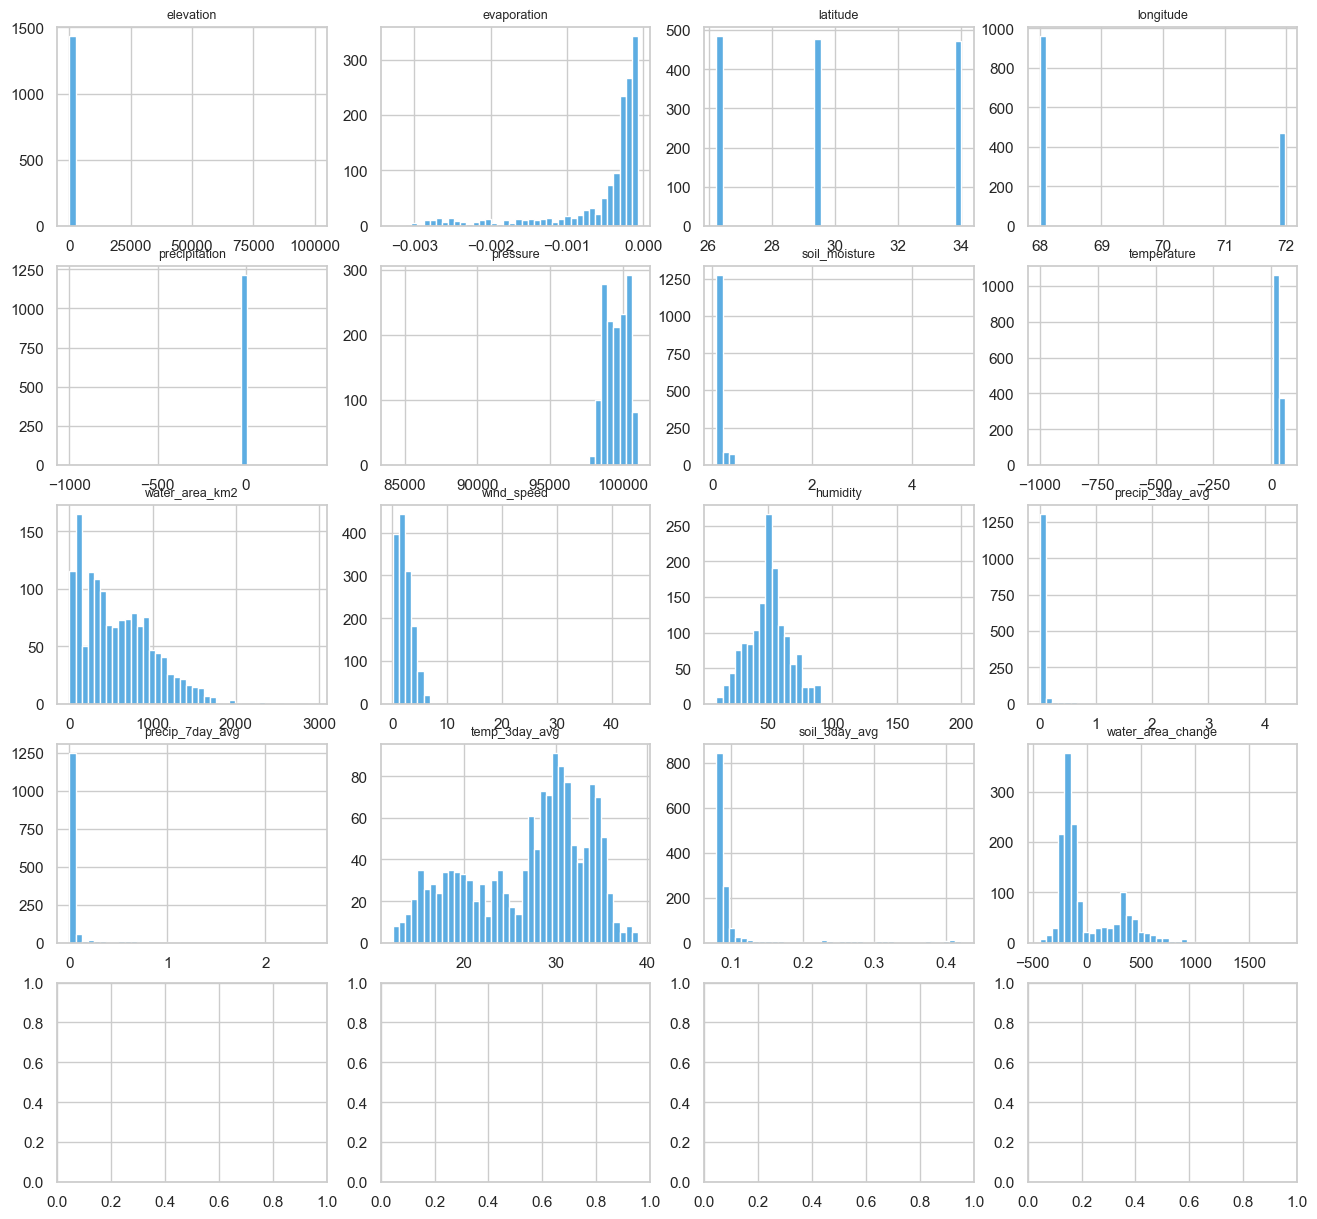

In [14]:
# Histogram grid
n = len(num_features)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col].dropna(), bins=40, color="#5DADE2", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Shapiro-Wilk normality test (sample of 500 rows for speed)
print("Shapiro-Wilk normality test (p < 0.05 → NOT normal):")
sample = df[num_features].dropna().sample(min(500, len(df)), random_state=42)

for col in num_features:
    stat, p = stats.shapiro(sample[col])
    flag = "❌ NOT normal" if p < 0.05 else "✅ Normal"
    print(f"  {col:30s}  p={p:.4f}  {flag}")

Shapiro-Wilk normality test (p < 0.05 → NOT normal):
  elevation                       p=0.0000  ❌ NOT normal
  evaporation                     p=0.0000  ❌ NOT normal
  latitude                        p=0.0000  ❌ NOT normal
  longitude                       p=0.0000  ❌ NOT normal
  precipitation                   p=0.0000  ❌ NOT normal
  pressure                        p=0.0000  ❌ NOT normal
  soil_moisture                   p=0.0000  ❌ NOT normal
  temperature                     p=0.0000  ❌ NOT normal
  water_area_km2                  p=0.0000  ❌ NOT normal
  wind_speed                      p=0.0000  ❌ NOT normal
  humidity                        p=0.0004  ❌ NOT normal
  precip_3day_avg                 p=0.0000  ❌ NOT normal
  precip_7day_avg                 p=0.0000  ❌ NOT normal
  temp_3day_avg                   p=0.0000  ❌ NOT normal
  soil_3day_avg                   p=0.0000  ❌ NOT normal
  water_area_change               p=0.0000  ❌ NOT normal
  water_area_pct_change           p

## 9. Box Plots - Outlier Inspection per Class

Focus: **Non-Flood class** (majority). We will use IQR to remove its outliers iteratively.


In [16]:
# Split by class for visual comparison
df_flood = df[df["flood_event"] == 1]
df_noflood = df[df["flood_event"] == 0]

print(f"Flood rows    : {len(df_flood)}")
print(f"Non-Flood rows: {len(df_noflood)}")

Flood rows    : 464
Non-Flood rows: 970


C:\Users\drstr\AppData\Local\Temp\ipykernel_24724\2980478621.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\drstr\AppData\Local\Temp\ipykernel_24724\2980478621.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\drstr\AppData\Local\Temp\ipykernel_24724\2980478621.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\drstr\AppData\Local\Temp\ipykernel_24724\2980478621.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will 

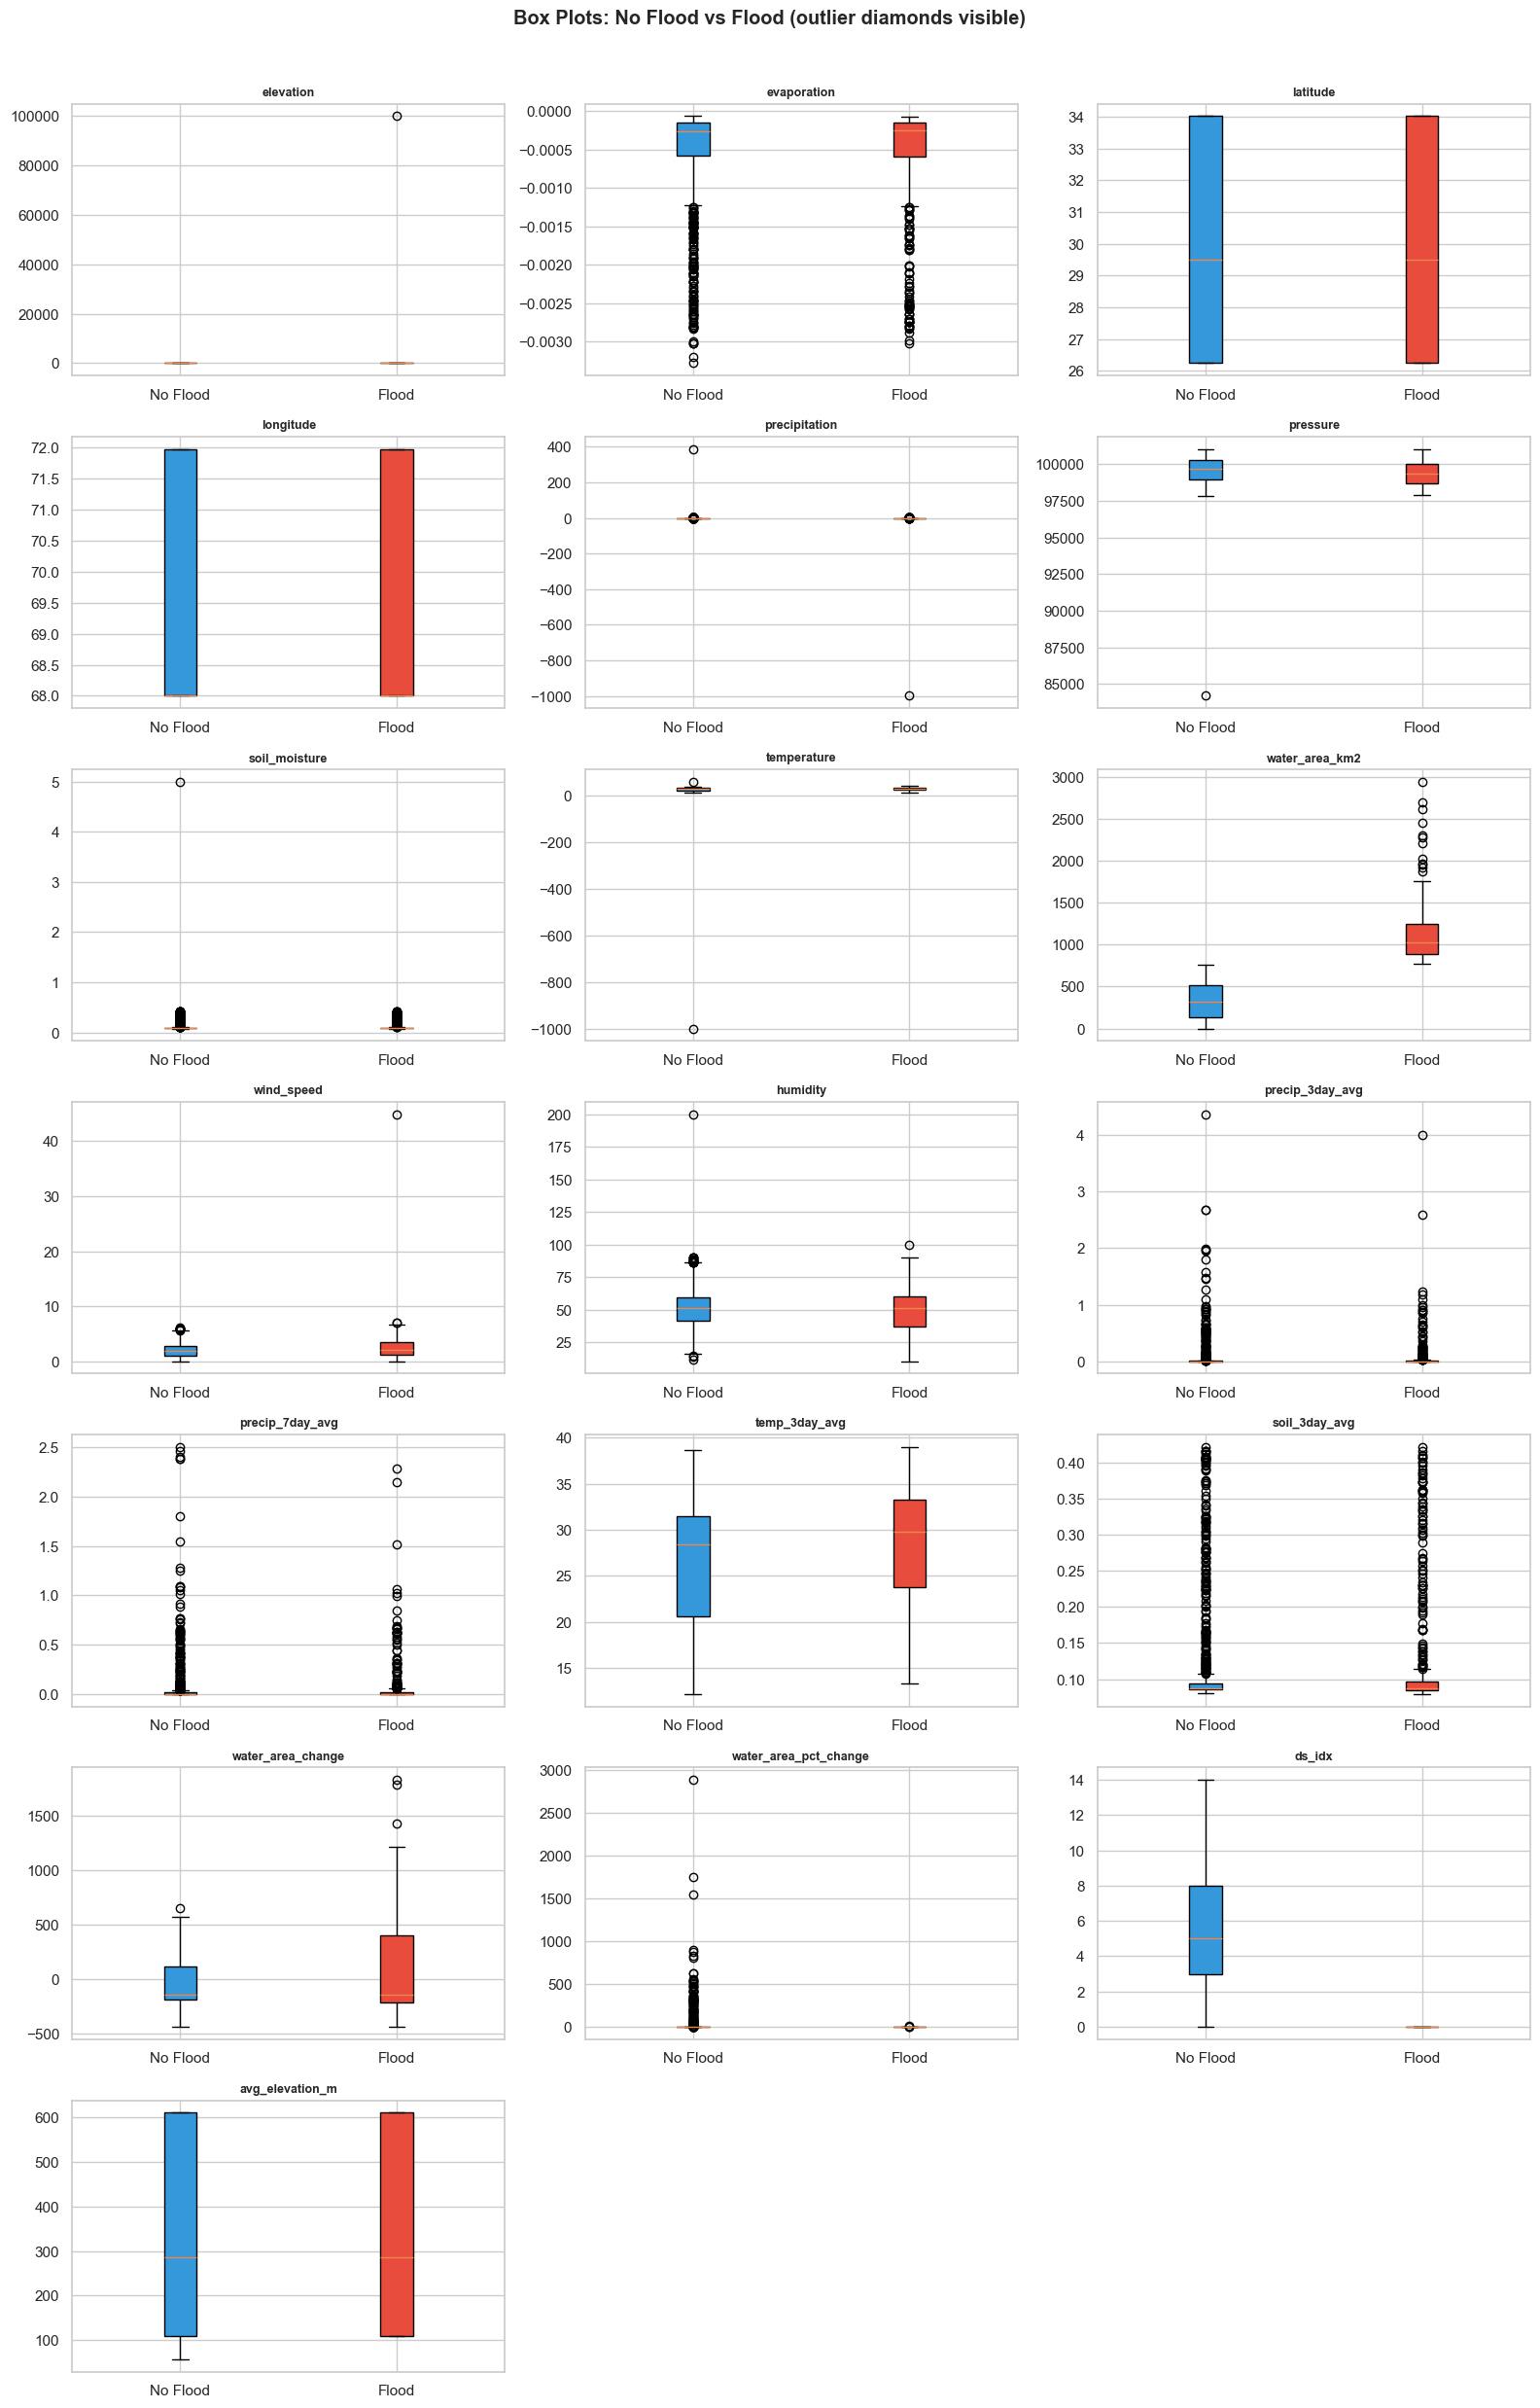

In [17]:
# Box plots: flood vs non-flood for each feature
plot_cols = [c for c in num_features if c in df.columns]
ncols = 3
nrows = (len(plot_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    data = [df_noflood[col].dropna().values, df_flood[col].dropna().values]
    bp = axes[i].boxplot(
        data, labels=["No Flood", "Flood"], patch_artist=True, notch=False
    )
    bp["boxes"][0].set_facecolor("#3498DB")
    bp["boxes"][1].set_facecolor("#E74C3C")
    axes[i].set_title(col, fontsize=9, fontweight="bold")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Box Plots: No Flood vs Flood (outlier diamonds visible)", fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

## 10. IQR Outlier Count per Feature (Non-Flood Class Only)


In [ ]:
# Count how many outliers exist in the non-flood majority class per feature
iqr_report = []
for col in num_features:
    series = df_noflood[col].dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((series < lo) | (series > hi)).sum()
    pct_out = n_out / len(series) * 100
    iqr_report.append(
        {
            "feature": col,
            "Q1": round(Q1, 2),
            "Q3": round(Q3, 2),
            "IQR": round(IQR, 2),
            "lower_fence": round(lo, 2),
            "upper_fence": round(hi, 2),
            "outlier_count": n_out,
            "outlier_%": round(pct_out, 2),
        }
    )

iqr_df = pd.DataFrame(iqr_report).sort_values("outlier_count", ascending=False)
print("IQR Outlier Analysis - NON-FLOOD class:")
display(iqr_df)

IQR Outlier Analysis — NON-FLOOD class:


,feature,Q1,Q3,IQR,lower_fence,upper_fence,outlier_count,outlier_%
11,precip_3day_avg,0.00,0.01,0.01,-0.01,0.02,188,19.40
6,soil_moisture,0.09,0.09,0.01,0.07,0.11,166,17.11
14,soil_3day_avg,0.09,0.09,0.01,0.07,0.11,163,16.82
12,precip_7day_avg,0.00,0.01,0.01,-0.02,0.04,161,16.62
16,water_area_pct_change,-0.50,0.43,0.92,-1.88,1.81,158,16.31
4,precipitation,0.00,0.00,0.00,-0.01,0.01,156,19.09
1,evaporation,-0.00,-0.00,0.00,-0.00,0.00,126,13.00
10,humidity,41.42,59.29,17.87,14.61,86.10,20,2.06
9,wind_speed,1.09,2.93,1.84,-1.66,5.68,9,0.93
7,temperature,20.78,31.38,10.59,4.89,47.26,2,0.21


In [19]:
# If we removed ALL non-flood outliers today, what would the class split become?
mask_noflood_outliers = pd.Series(False, index=df_noflood.index)

for col in num_features:
    series = df_noflood[col].dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    is_out = (df_noflood[col] < lo) | (df_noflood[col] > hi)
    mask_noflood_outliers |= is_out.fillna(False)

n_removed = mask_noflood_outliers.sum()
n_noflood_after = len(df_noflood) - n_removed
n_flood = len(df_flood)
total_after = n_noflood_after + n_flood

print(f"Non-flood rows before : {len(df_noflood)}")
print(f"Outliers to remove    : {n_removed}")
print(
    f"Non-flood rows after  : {n_noflood_after}  ({n_noflood_after/total_after*100:.1f}%)"
)
print(f"Flood rows (unchanged): {n_flood}           ({n_flood/total_after*100:.1f}%)")
print(f"\nNew ratio (non-flood : flood) ≈ {n_noflood_after/n_flood:.2f} : 1")

Non-flood rows before : 970
Outliers to remove    : 417
Non-flood rows after  : 553  (54.4%)
Flood rows (unchanged): 464           (45.6%)

New ratio (non-flood : flood) ≈ 1.19 : 1


## 11. Correlation Analysis


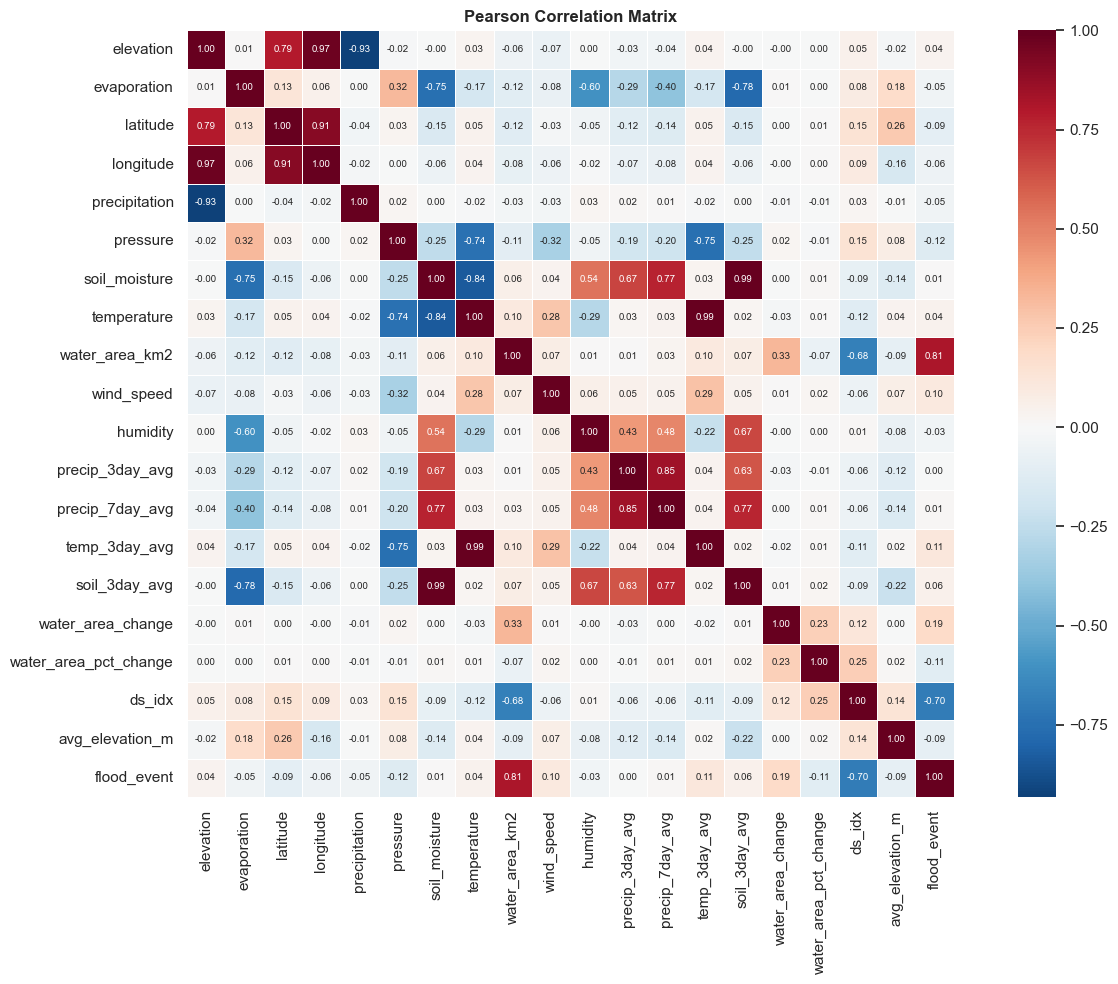

In [20]:
# Pearson correlation matrix
corr_cols = [c for c in num_features] + ["flood_event"]
corr = df[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={"size": 7},
)
plt.title("Pearson Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

In [21]:
# Point-biserial correlation with target (flood_event)
from scipy.stats import pointbiserialr

pb_rows = []
for col in num_features:
    valid = df[["flood_event", col]].dropna()
    r, p = pointbiserialr(valid["flood_event"], valid[col])
    pb_rows.append({"feature": col, "correlation": round(r, 4), "p_value": round(p, 5)})

pb_df = pd.DataFrame(pb_rows).sort_values("correlation", key=abs, ascending=False)
print("Point-Biserial Correlation with flood_event (|r| sorted):")
display(pb_df)

Point-Biserial Correlation with flood_event (|r| sorted):


c:\Users\drstr\Downloads\BNU_Fest\.venv\Lib\site-packages\scipy\stats\_stats_py.py:4735: RuntimeWarning: invalid value encountered in subtract
  ym = y - ymean


,feature,correlation,p_value
8,water_area_km2,0.8136,0.00000
17,ds_idx,-0.6962,0.00000
15,water_area_change,0.1885,0.00000
5,pressure,-0.1249,0.00000
13,temp_3day_avg,0.1102,0.00003
9,wind_speed,0.0967,0.00025
2,latitude,-0.0944,0.00035
18,avg_elevation_m,-0.0933,0.00040
14,soil_3day_avg,0.0563,0.03306
3,longitude,-0.0559,0.03433


## 12. Feature Means - Flood vs No-Flood


In [22]:
means = df.groupby("flood_event")[num_features].mean().T
means.columns = ["No Flood", "Flood"]
means["diff_%"] = (
    (means["Flood"] - means["No Flood"]) / (means["No Flood"].abs() + 1e-9) * 100
).round(1)
means = means.sort_values("diff_%", key=abs, ascending=False)
print("Feature means per class and % difference:")
display(means)

Feature means per class and % difference:


,No Flood,Flood,diff_%
precipitation,5.284015e-01,-2.437447,-561.3
water_area_change,-3.878195e+01,77.510829,299.9
water_area_km2,3.370970e+02,1104.951388,227.8
elevation,1.487317e+02,357.849138,140.6
ds_idx,5.367389e+00,0.000000,-100.0
wind_speed,2.135257e+00,2.503924,17.3
evaporation,-5.379752e-04,-0.000609,-13.2
avg_elevation_m,3.467340e+02,305.271552,-12.0
precip_7day_avg,6.162388e-02,0.068102,10.5
temperature,2.552230e+01,28.128971,10.2


## 13. Time Series Patterns


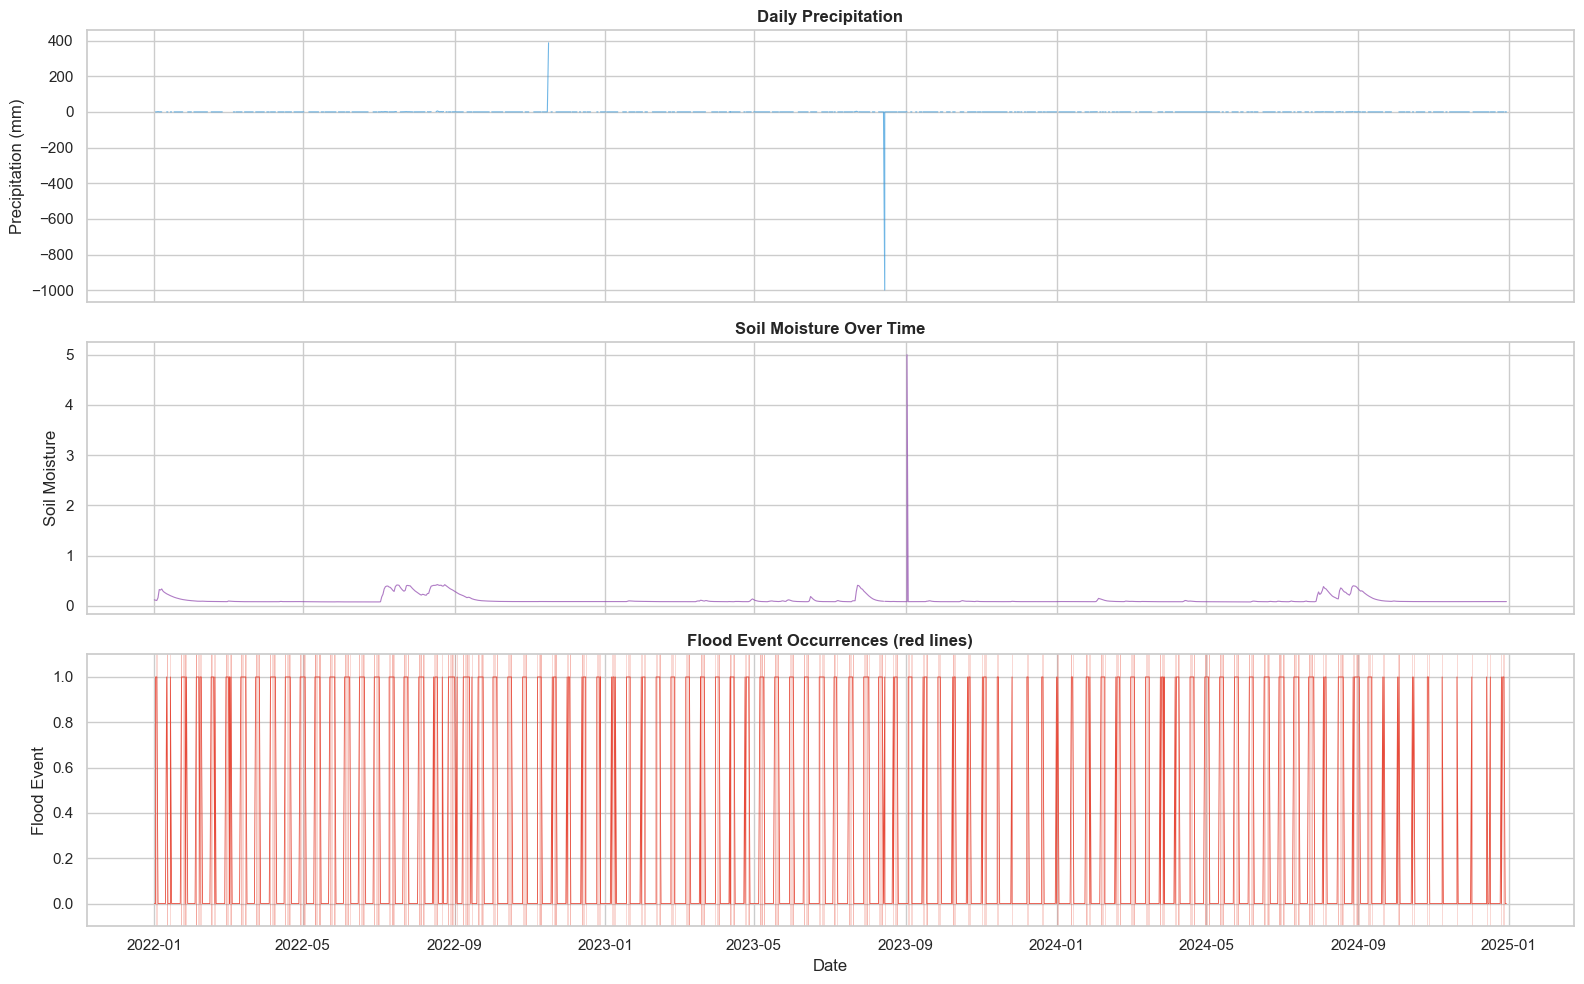

In [23]:
# Daily precipitation and flood events over time
ts = df.sort_values("date").copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].plot(ts["date"], ts["precipitation"], color="#3498DB", lw=0.8, alpha=0.7)
axes[0].set_ylabel("Precipitation (mm)")
axes[0].set_title("Daily Precipitation", fontweight="bold")

axes[1].plot(ts["date"], ts["soil_moisture"], color="#8E44AD", lw=0.8, alpha=0.7)
axes[1].set_ylabel("Soil Moisture")
axes[1].set_title("Soil Moisture Over Time", fontweight="bold")

# Flood events as vertical markers
flood_dates = ts[ts["flood_event"] == 1]["date"]
for d in flood_dates:
    axes[2].axvline(d, color="#E74C3C", alpha=0.3, lw=0.5)
axes[2].set_ylabel("Flood Event")
axes[2].set_title("Flood Event Occurrences (red lines)", fontweight="bold")
axes[2].set_ylim(-0.1, 1.1)
axes[2].plot(ts["date"], ts["flood_event"], color="#E74C3C", lw=0.6)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 14. Seasonal / Monthly Patterns


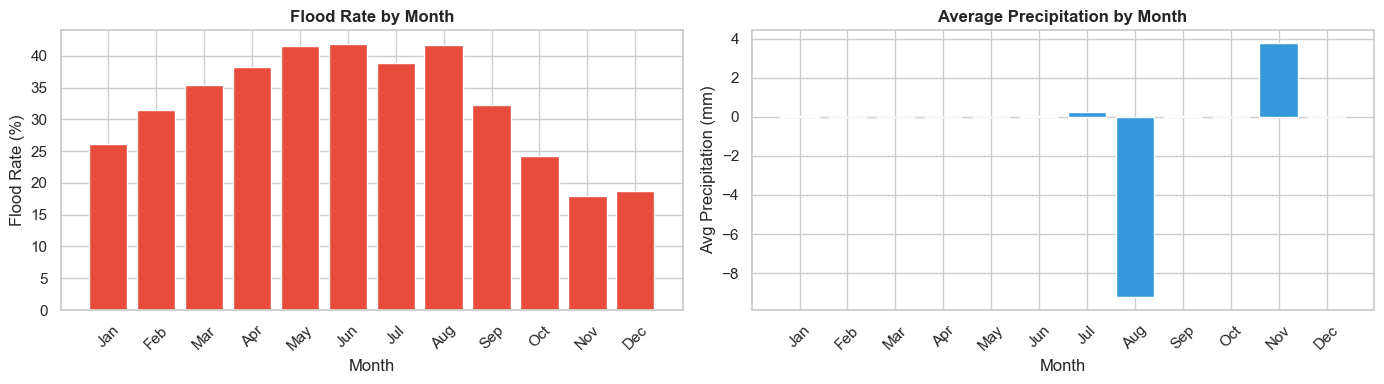

 month  flood_rate_%  n_rows
     1          26.2     122
     2          31.5     111
     3          35.4     127
     4          38.3     115
     5          41.5     123
     6          41.9     117
     7          38.8     121
     8          41.7     120
     9          32.2     118
    10          24.2     120
    11          17.9     117
    12          18.7     123


In [24]:
# Flood rate per month
monthly = (
    df.groupby("month")
    .agg(flood_rate=("flood_event", "mean"), n_rows=("flood_event", "count"))
    .reset_index()
)
monthly["flood_rate_%"] = (monthly["flood_rate"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(monthly["month"], monthly["flood_rate_%"], color="#E74C3C")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Flood Rate (%)")
axes[0].set_title("Flood Rate by Month", fontweight="bold")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(
    [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ],
    rotation=45,
)

# Average precipitation per month
monthly_precip = df.groupby("month")["precipitation"].mean()
axes[1].bar(monthly_precip.index, monthly_precip.values, color="#3498DB")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg Precipitation (mm)")
axes[1].set_title("Average Precipitation by Month", fontweight="bold")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(
    [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ],
    rotation=45,
)

plt.tight_layout()
plt.show()
print(monthly[["month", "flood_rate_%", "n_rows"]].to_string(index=False))

In [ ]:
# Monsoon vs non-monsoon flood rate
monsoon = df.groupby("is_monsoon").agg(
    flood_rate=("flood_event", "mean"), n_rows=("flood_event", "count")
)
monsoon.index = ["Non-Monsoon", "Monsoon"]
monsoon["flood_rate_%"] = (monsoon["flood_rate"] * 100).round(1)
print("Flood rate - Monsoon vs Non-Monsoon:")
print(monsoon[["flood_rate_%", "n_rows"]])

Flood rate — Monsoon vs Non-Monsoon:
             flood_rate_%  n_rows
Non-Monsoon          29.2     958
Monsoon              38.7     476


## 15. Summary & Notes for Modelling Notebook

Run all cells above, then note findings below for the modelling notebook.

| Item                       | Finding                    |
| -------------------------- | -------------------------- |
| Shape                      | _(fill after running)_     |
| Missing values             | _(fill after running)_     |
| Duplicates                 | _(fill after running)_     |
| Class balance              | ~32% flood / 68% non-flood |
| Inf values                 | _(fill after running)_     |
| Non-normal features        | _(fill after running)_     |
| Top correlated features    | _(fill after running)_     |
| Outlier count in non-flood | _(fill after running)_     |
